# EDA — Mid-Block Traffic Calming Areas

Este notebook analiza el dataset de medidas de calmado de tráfico instaladas en tramos de calle (*mid-block*). Además, investiga cómo unirlo con los datasets de accidentes con lesiones, accidentes fatales y PCI histórico.

**Idea clave:** este dataset está a nivel de **segmento vial**, por lo que su clave natural es `cnn`, que debe cruzarse principalmente con `cnn_sgmt_fkey` en accidentes con lesiones y con `CNN` en PCI.

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

CANDIDATE_DIRS = [Path.cwd(), Path.cwd().parent, Path("/mnt/data")]

def resolve_file(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    raise FileNotFoundError(f"No encontré {filename}. Colócalo en la misma carpeta del notebook o en /mnt/data.")

def read_csv_resolved(filename: str, **kwargs) -> pd.DataFrame:
    path = resolve_file(filename)
    print(f"Leyendo: {path}")
    return pd.read_csv(path, low_memory=False, **kwargs)

NULL_TOKENS = ["<Null>", "NULL", "Null", "null", "None", ""]

def normalize_nulls(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.replace(NULL_TOKENS, np.nan)
    return out

def to_int_key(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": [name],
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "duplicated_rows": [df.duplicated().sum()],
        "memory_mb": [round(df.memory_usage(deep=True).sum() / 1024**2, 2)]
    })

def missing_report(df: pd.DataFrame) -> pd.DataFrame:
    rep = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "nunique": df.nunique(dropna=True).values,
    })
    return rep.sort_values(["missing_pct", "missing"], ascending=False).reset_index(drop=True)

def top_values(df: pd.DataFrame, col: str, n: int = 15) -> pd.DataFrame:
    s = df[col]
    out = s.value_counts(dropna=False).head(n).rename_axis(col).reset_index(name="count")
    out["pct"] = (out["count"] / len(df) * 100).round(2)
    return out

def key_match_report(left_df, left_col, right_df, right_col, left_name, right_name):
    left = to_int_key(left_df[left_col]).dropna()
    right = to_int_key(right_df[right_col]).dropna()
    left_unique = pd.Index(left.unique())
    right_unique = pd.Index(right.unique())
    right_set = set(right_unique.astype("int64"))
    row_matches = left.astype("int64").isin(right_set).sum()
    unique_matches = left_unique.isin(right_unique).sum()
    return {
        "left": f"{left_name}.{left_col}",
        "right": f"{right_name}.{right_col}",
        "left_non_null_rows": int(len(left)),
        "left_unique_keys": int(left.nunique()),
        "right_non_null_rows": int(len(right)),
        "right_unique_keys": int(right.nunique()),
        "matched_left_rows": int(row_matches),
        "matched_left_rows_pct": round(row_matches / len(left) * 100, 2) if len(left) else np.nan,
        "matched_left_unique_keys": int(unique_matches),
        "matched_left_unique_keys_pct": round(unique_matches / left.nunique() * 100, 2) if left.nunique() else np.nan,
    }

def barh_value_counts(df, col, title=None, n=15):
    vc = df[col].value_counts(dropna=False).head(n).sort_values()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(vc))))
    vc.plot(kind="barh", ax=ax)
    ax.set_title(title or f"Top {n}: {col}")
    ax.set_xlabel("Número de registros")
    ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()

def plot_year_counts(df, year_col, title):
    s = pd.to_numeric(df[year_col], errors="coerce")
    s = s[(s >= 1900) & (s <= 2030)]
    counts = s.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(11, 4))
    counts.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Año")
    ax.set_ylabel("Número de registros")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [ ]:

MID_BLOCK_FILE = "./mid-calming.csv"
INTERSECTION_FILE = "./intersection-calming.csv"
INJURY_FILE = "./accidentes-injury-histo.csv"
FATALITY_FILE = "./accidentes-fatality-histo.csv"
PCI_FILE = "./PCI-histo.csv"

mid_raw = read_csv_resolved(MID_BLOCK_FILE)
intersection_raw = read_csv_resolved(INTERSECTION_FILE)

INJURY_USECOLS = [
    "unique_id", "case_id_pkey", "cnn_sgmt_fkey", "cnn_intrsctn_fkey",
    "collision_datetime", "primary_rd", "secondary_rd", "intersection",
    "collision_severity", "number_injured", "number_killed"
]
FATALITY_USECOLS = [
    "unique_id", "case_id_fkey", "collision_datetime", "location",
    "deceased", "collision_type", "point"
]
PCI_USECOLS = ["CNN", "PCI_Score", "PCI_Change_Date", "Functional_Class"]

injury_raw = read_csv_resolved(INJURY_FILE, usecols=INJURY_USECOLS)
fatality_raw = read_csv_resolved(FATALITY_FILE, usecols=FATALITY_USECOLS)
pci_raw = read_csv_resolved(PCI_FILE, usecols=PCI_USECOLS)

mid = normalize_nulls(mid_raw)
intersection = normalize_nulls(intersection_raw)
injury = normalize_nulls(injury_raw)
fatality = normalize_nulls(fatality_raw)
pci = normalize_nulls(pci_raw)

mid["cnn_key"] = to_int_key(mid["cnn"])
intersection["cnn_key"] = to_int_key(intersection["cnn"])
injury["cnn_sgmt_key"] = to_int_key(injury["cnn_sgmt_fkey"])
injury["cnn_intrsctn_key"] = to_int_key(injury["cnn_intrsctn_fkey"])
fatality["case_id_key"] = to_int_key(fatality["case_id_fkey"])
injury["case_id_key"] = to_int_key(injury["case_id_pkey"])
pci["cnn_key"] = to_int_key(pci["CNN"])

mid["install_dt"] = pd.to_datetime(mid["install_datetime"], errors="coerce")
intersection["install_dt"] = pd.to_datetime(intersection["install_date"], errors="coerce")
injury["collision_dt"] = pd.to_datetime(injury["collision_datetime"], errors="coerce")
fatality["collision_dt"] = pd.to_datetime(fatality["collision_datetime"], errors="coerce")
pci["pci_change_dt"] = pd.to_datetime(pci["PCI_Change_Date"], errors="coerce")

mid["install_dt_clean"] = mid["install_dt"].mask(mid["install_dt"].dt.year.eq(1900))
intersection["install_dt_clean"] = intersection["install_dt"].mask(intersection["install_dt"].dt.year.eq(1900))

summary = pd.concat([
    overview(mid, "mid_block_calming_full"),
    overview(intersection, "intersection_calming_full"),
    overview(injury, "injury_crashes_join_columns"),
    overview(fatality, "fatality_crashes_join_columns"),
    overview(pci, "pci_history_join_columns"),
], ignore_index=True)
display(summary)


Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\mid-calming.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\intersection-calming.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\accidentes-injury-histo.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\accidentes-fatality-histo.csv
Leyendo: c:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\PCI-histo.csv


,dataset,rows,columns,duplicated_rows,memory_mb
0,mid_block_calming_full,1686,26,0,2.04
1,intersection_calming_full,355,22,0,0.29
2,injury_crashes_join_columns,64694,15,0,28.57
3,fatality_crashes_join_columns,359,9,0,0.15
4,pci_history_join_columns,307133,6,2409,47.65


## 1. Estructura del dataset mid-block

In [3]:
display(mid.head())
display(pd.DataFrame({"column": mid.columns, "dtype": mid.dtypes.astype(str)}))
print(f"Filas: {mid.shape[0]:,}")
print(f"Columnas: {mid.shape[1]:,}")
print(f"CNN únicos: {mid['cnn_key'].nunique(dropna=True):,}")
print(f"Filas duplicadas exactas: {mid.duplicated().sum():,}")

,row_id,objectid,cnn,nhood,streetname,district,from_st,to_st,project_location,tc_measure,units,install_mo,install_yr,install_datetime,fiscal_yr,program,current_status,current_ti,next_step,next_step_2,shape,data_as_of,data_loaded_at,cnn_key,install_dt,install_dt_clean
0,1,24264.0,8539000.0,Ingleside Terrace,LUNADO WAY,7,LUNADO CT,CERRITOS AVE \ MERCEDES WY,Lunado Way from Lunado Court to Cerritos Avenu...,Speed Hump,0,0,0,1900/01/01,FY 2013-2014,NaN,Obsolete,NaN,NaN,NaN,"LINESTRING (-122.471186243 37.725934637, -122....",2026/05/23 10:19:56 AM,2026/05/23 10:48:09 AM,8539000,1900-01-01,NaT
1,3,28003.0,5201000.0,Bernal Heights,ELLSWORTH ST,9,CRESCENT AVE,ALEMANY BLVD \ I-280 S OFF RAMP \ I-280 S ON RAMP,Ellsworth Street from Crescent Avenue to Alema...,5-Lump Speed Cushion,2,4,2021,2021/04/01,FY 2019-2020,App-Based,Complete,NaN,NaN,NaN,"LINESTRING (-122.414934763 37.734793888, -122....",2026/05/23 10:19:56 AM,2026/05/23 10:48:09 AM,5201000,2021-04-01,2021-04-01
2,4,26889.0,6188000.0,Bret Harte,GILMAN AVE,10,GRIFFITH ST,HAWES ST,Gilman Avenue from Griffith Street to Hawes St...,NaN,NaN,NaN,NaN,NaN,FY 2022-2023,App-Based,Pending design review and approval,Jul - Dec 2024,Pending construction,Jan - Jul 2025,"LINESTRING (-122.388136868 37.718235643, -122....",2026/05/23 10:19:56 AM,2026/05/23 10:48:09 AM,6188000,NaT,NaT
3,5,21605.0,10814000.0,Bayview District,QUESADA AVE,10,KEITH ST,LANE ST,Quesada Avenue from Keith Street to Lane Street,Traffic Island,1,4,2008,2008/04/01,FY 2007-2008,Areawide,Complete,NaN,NaN,NaN,"LINESTRING (-122.38772939 37.731231789, -122.3...",2026/05/23 10:19:56 AM,2026/05/23 10:48:09 AM,10814000,2008-04-01,2008-04-01
4,6,19439.0,12829000.0,Bayview District,UNDERWOOD AVE,10,KEITH ST,LANE ST,Underwood Avenue from Keith Street to Lane Street,Speed Hump,1,0,0,1900/01/01,NaN,Areawide,Complete,NaN,NaN,NaN,"LINESTRING (-122.389981317 37.728728463, -122....",2026/05/23 10:19:56 AM,2026/05/23 10:48:09 AM,12829000,1900-01-01,NaT


,column,dtype
row_id,row_id,int64
objectid,objectid,float64
cnn,cnn,float64
nhood,nhood,str
streetname,streetname,str
district,district,str
from_st,from_st,str
to_st,to_st,str
project_location,project_location,str
tc_measure,tc_measure,str


Filas: 1,686
Columnas: 26
CNN únicos: 1,608
Filas duplicadas exactas: 0


## 2. Calidad de datos

Se revisan nulos, fechas dummy, duplicados y cardinalidad. `install_datetime = 1900-01-01` e `install_yr = 0` deben tratarse como fecha desconocida, no como una instalación real.

In [4]:

miss_mid = missing_report(mid)
display(miss_mid)

quality_mid = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "exact_duplicates",
        "cnn_missing",
        "cnn_unique",
        "install_dt_missing_raw",
        "install_dt_dummy_1900",
        "install_dt_missing_or_dummy",
        "status_missing",
        "tc_measure_missing"
    ],
    "value": [
        len(mid),
        mid.shape[1],
        mid.duplicated().sum(),
        mid["cnn_key"].isna().sum(),
        mid["cnn_key"].nunique(dropna=True),
        mid["install_dt"].isna().sum(),
        mid["install_dt"].dt.year.eq(1900).sum(),
        mid["install_dt_clean"].isna().sum(),
        mid["current_status"].isna().sum(),
        mid["tc_measure"].isna().sum(),
    ]
})
display(quality_mid)


,column,dtype,missing,missing_pct,nunique
0,next_step_2,str,1302,77.22,3
1,current_ti,str,1297,76.93,5
2,next_step,str,1292,76.63,5
3,install_dt_clean,datetime64[us],618,36.65,146
4,install_mo,str,453,26.87,21
5,install_datetime,str,453,26.87,147
6,install_dt,datetime64[us],453,26.87,147
7,install_yr,str,438,25.98,21
8,objectid,float64,403,23.90,1247
9,fiscal_yr,str,393,23.31,32


,metric,value
0,rows,1686
1,columns,26
2,exact_duplicates,0
3,cnn_missing,1
4,cnn_unique,1608
5,install_dt_missing_raw,453
6,install_dt_dummy_1900,165
7,install_dt_missing_or_dummy,618
8,status_missing,40
9,tc_measure_missing,294


## 3. Distribuciones principales

### Distribución de `current_status`

,current_status,count,pct
0,Complete,1225,72.66
1,Pending data collection and evaluation,161,9.55
2,Pending design review and approval,121,7.18
3,Pending construction,110,6.52
4,NaN,40,2.37
5,Obsolete,28,1.66
6,Data collection and evaluation,1,0.06


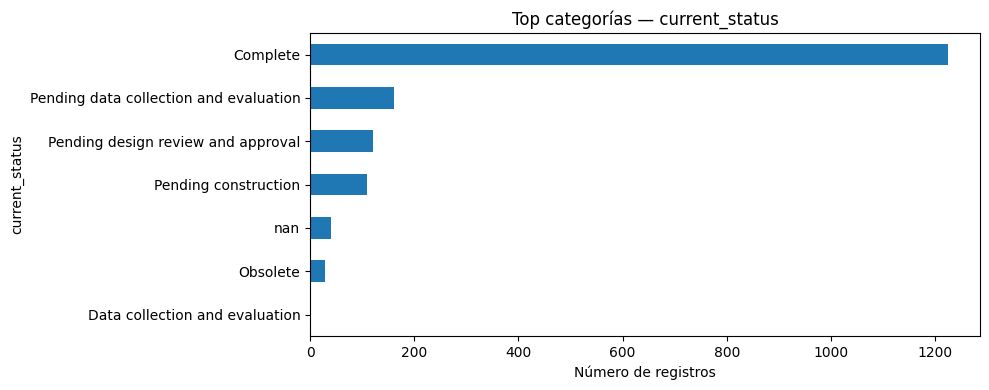

### Distribución de `tc_measure`

,tc_measure,count,pct
0,Speed Hump,566,33.57
1,3-Lump Speed Cushion,402,23.84
2,NaN,294,17.44
3,5-Lump Speed Cushion,133,7.89
4,Speed Table,82,4.86
5,Speed Bump,40,2.37
6,Speed Cushion,37,2.19
7,Edgeline,32,1.90
8,4-Lump Speed Cushion,22,1.30
9,Raised Crosswalk,18,1.07


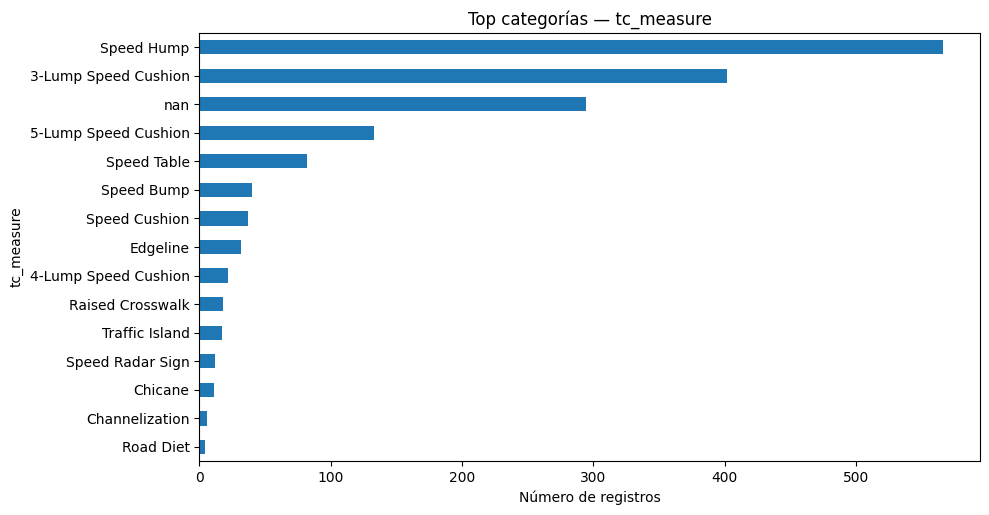

### Distribución de `program`

,program,count,pct
0,App-Based,902,53.50
1,NaN,123,7.30
2,D11 NTIP,74,4.39
3,TC Implementation,62,3.68
4,Areawide,59,3.50
5,Site Specific,59,3.50
6,FY 2025 D11 NTIP,36,2.14
7,Great Highway Traffic Management,24,1.42
8,Excelsior Neighborhood Traffic Calming Project,19,1.13
9,Schools Engineering Loading Zone TC,19,1.13


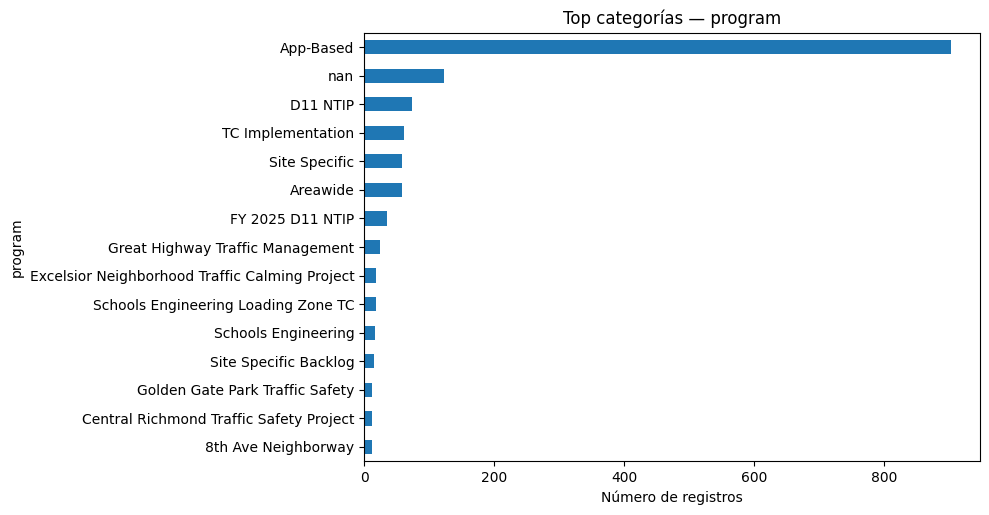

### Distribución de `fiscal_yr`

,fiscal_yr,count,pct
0,NaN,393,23.31
1,FY 2021-2022,199,11.80
2,FY 2020-2021,127,7.53
3,FY 2019-2020,116,6.88
4,FY 2018-2019,114,6.76
5,FY 2011-2012,69,4.09
6,FY 2017-2018,64,3.80
7,FY 2016-2017,59,3.50
8,FY 2015-2016,57,3.38
9,FY 2013-2014,51,3.02


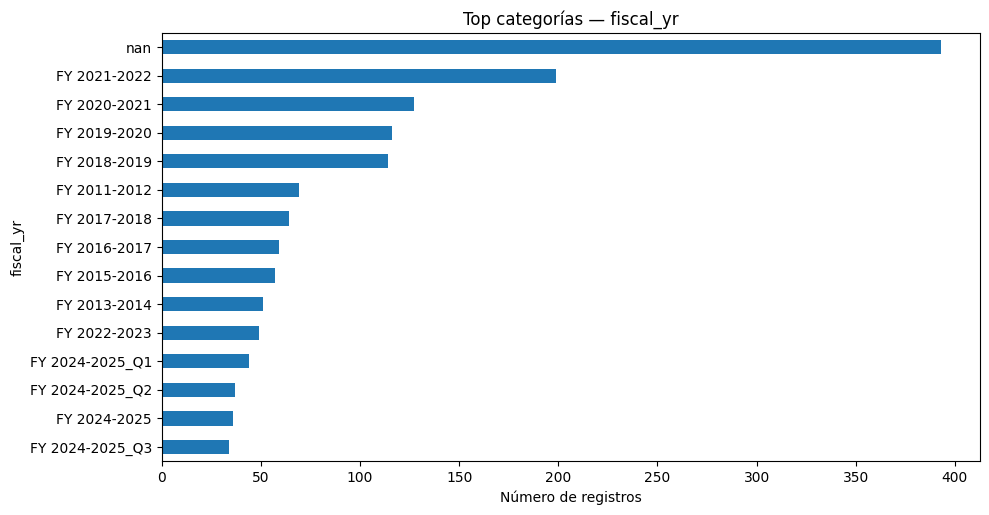

### Distribución de `district`

,district,count,pct
0,7,290,17.20
1,10,272,16.13
2,11,255,15.12
3,8,196,11.63
4,4,184,10.91
5,9,172,10.20
6,1,142,8.42
7,2,57,3.38
8,6,33,1.96
9,5,29,1.72


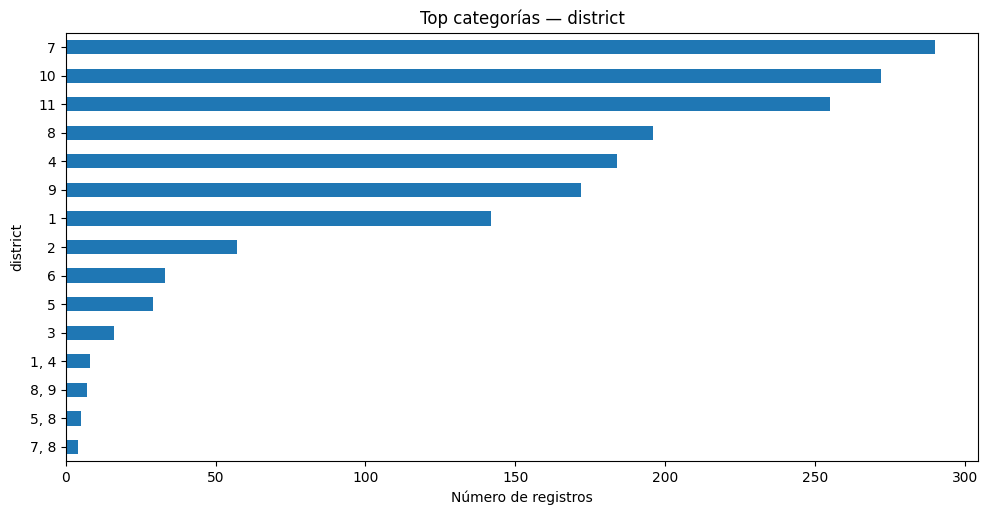

### Distribución de `nhood`

,nhood,count,pct
0,Outer Sunset,108,6.41
1,Excelsior,81,4.80
2,Bayview District,79,4.69
3,Inner Richmond,56,3.32
4,Parkside,46,2.73
5,Outer Richmond,46,2.73
6,Noe Valley,46,2.73
7,Bernal Heights,43,2.55
8,Mission District,40,2.37
9,Silver Terrace,38,2.25


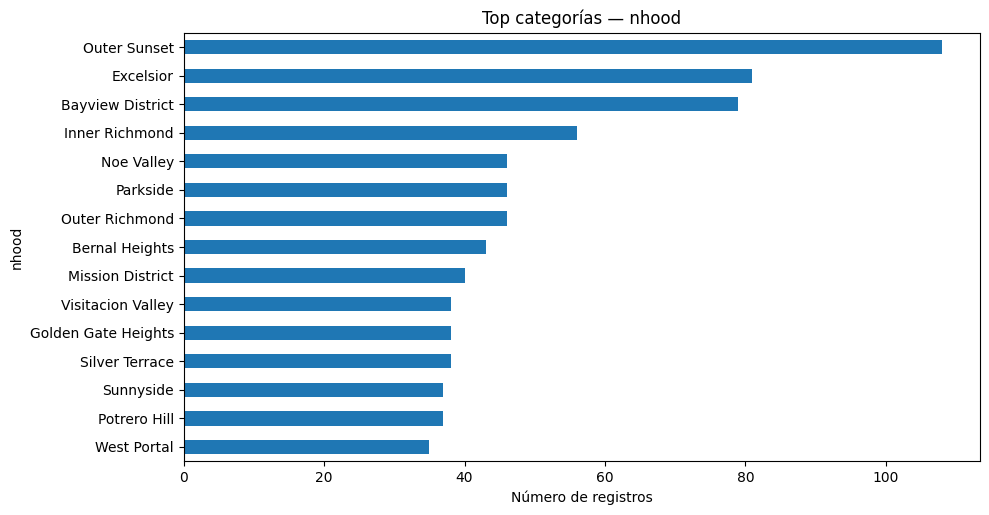

In [ ]:
for col in ["current_status", "tc_measure", "program", "fiscal_yr", "district", "nhood"]:
    if col in mid.columns:
        display(Markdown(f"### Distribución de `{col}`"))
        display(top_values(mid, col, n=20))
        barh_value_counts(mid, col, title=f"Top categorías — {col}", n=15)


## 4. Variables temporales

Se analiza la instalación por año. Para modelado, no se deben usar fechas 1900 como fechas reales.

,min_install_dt_clean,max_install_dt_clean,known_install_dates,unknown_install_dates
0,2004-07-01,2026-05-01,1068,618


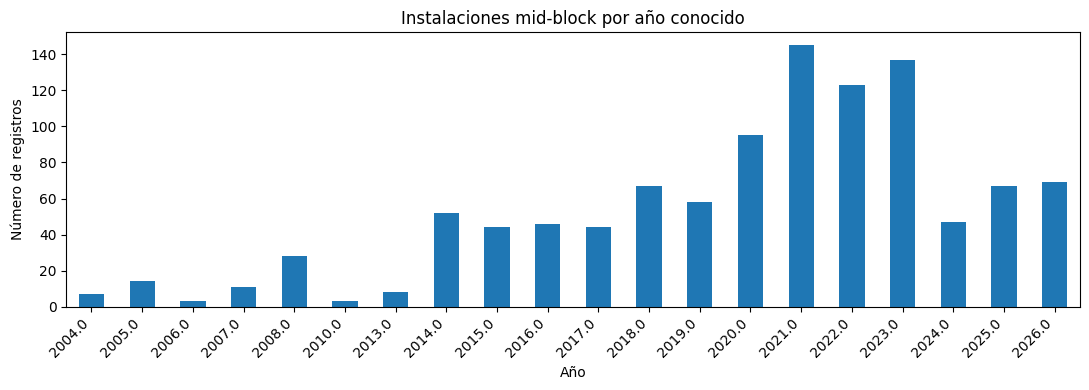

,install_year_clean,current_status,count
0,2004.0,Complete,7
1,2005.0,Complete,13
2,2005.0,Obsolete,1
3,2006.0,Complete,3
4,2007.0,Complete,10
5,2007.0,Obsolete,1
6,2008.0,Complete,28
7,2010.0,Complete,3
8,2013.0,Complete,7
9,2013.0,Obsolete,1


In [6]:

mid["install_year_clean"] = mid["install_dt_clean"].dt.year

display(pd.DataFrame({
    "min_install_dt_clean": [mid["install_dt_clean"].min()],
    "max_install_dt_clean": [mid["install_dt_clean"].max()],
    "known_install_dates": [mid["install_dt_clean"].notna().sum()],
    "unknown_install_dates": [mid["install_dt_clean"].isna().sum()],
}))

plot_year_counts(mid.dropna(subset=["install_year_clean"]), "install_year_clean", "Instalaciones mid-block por año conocido")

yearly_status = (mid.dropna(subset=["install_year_clean"])
                 .groupby(["install_year_clean", "current_status"], dropna=False)
                 .size()
                 .reset_index(name="count")
                 .sort_values(["install_year_clean", "count"], ascending=[True, False]))
display(yearly_status.head(40))


## 5. Revisión geográfica básica

`shape` contiene geometrías `LINESTRING`, por lo que este dataset representa tramos lineales. El bloque siguiente calcula longitudes aproximadas con `geopandas` y `shapely`.

,valid_geometries,missing_or_invalid_geometries,median_length_m,p95_length_m
0,1685,1,176.7972,276.678889


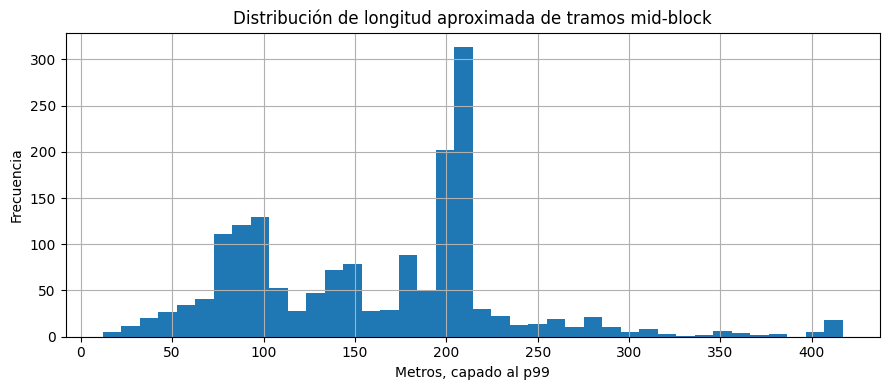

In [7]:

try:
    import geopandas as gpd
    from shapely import wkt

    def parse_wkt_safe(x):
        if pd.isna(x):
            return None
        try:
            return wkt.loads(x)
        except Exception:
            return None

    mid_geo = mid.copy()
    mid_geo["geometry"] = mid_geo["shape"].apply(parse_wkt_safe)
    mid_gdf = gpd.GeoDataFrame(mid_geo, geometry="geometry", crs="EPSG:4326")
    valid_lines = mid_gdf[mid_gdf.geometry.notna()].copy()
    valid_lines_proj = valid_lines.to_crs(epsg=2227)  # California StatePlane; longitud en pies aprox.
    valid_lines["length_ft_approx"] = valid_lines_proj.geometry.length
    valid_lines["length_m_approx"] = valid_lines["length_ft_approx"] * 0.3048

    display(pd.DataFrame({
        "valid_geometries": [len(valid_lines)],
        "missing_or_invalid_geometries": [mid_gdf.geometry.isna().sum()],
        "median_length_m": [valid_lines["length_m_approx"].median()],
        "p95_length_m": [valid_lines["length_m_approx"].quantile(0.95)]
    }))

    fig, ax = plt.subplots(figsize=(9, 4))
    valid_lines["length_m_approx"].clip(upper=valid_lines["length_m_approx"].quantile(0.99)).hist(bins=40, ax=ax)
    ax.set_title("Distribución de longitud aproximada de tramos mid-block")
    ax.set_xlabel("Metros, capado al p99")
    ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("No se pudo ejecutar la parte geoespacial opcional:", repr(e))


## 6. Investigación de unión con otros datasets

- `mid.cnn` ↔ `injury.cnn_sgmt_fkey`: unión por segmento vial del accidente.
- `mid.cnn` ↔ `pci.CNN`: unión por segmento vial para añadir condición de pavimento.
- `mid.cnn` **no** debería unirse con `injury.cnn_intrsctn_fkey`, porque esa columna representa intersecciones.
- Fatalidades no tienen `CNN` directo; se puede recuperar vía `fatality.case_id_fkey = injury.case_id_pkey` o mediante cruce espacial con `fatality.point`.

In [8]:

join_reports_mid = pd.DataFrame([
    key_match_report(mid, "cnn", pci, "CNN", "mid", "pci"),
    key_match_report(mid, "cnn", injury, "cnn_sgmt_fkey", "mid", "injury"),
    key_match_report(mid, "cnn", injury, "cnn_intrsctn_fkey", "mid", "injury"),
    key_match_report(injury, "cnn_sgmt_fkey", mid, "cnn", "injury", "mid"),
    key_match_report(injury, "cnn_intrsctn_fkey", mid, "cnn", "injury", "mid"),
])
display(join_reports_mid)


,left,right,left_non_null_rows,left_unique_keys,right_non_null_rows,right_unique_keys,matched_left_rows,matched_left_rows_pct,matched_left_unique_keys,matched_left_unique_keys_pct
0,mid.cnn,pci.CNN,1685,1608,307133,18349,1660,98.52,1584,98.51
1,mid.cnn,injury.cnn_sgmt_fkey,1685,1608,28914,7547,889,52.76,837,52.05
2,mid.cnn,injury.cnn_intrsctn_fkey,1685,1608,64657,6200,0,0.00,0,0.00
3,injury.cnn_sgmt_fkey,mid.cnn,28914,7547,1685,1608,2046,7.08,837,11.09
4,injury.cnn_intrsctn_fkey,mid.cnn,64657,6200,1685,1608,0,0.00,0,0.00


## 7. Unión con accidentes/Injury

No conviene unir fila a fila sin agregar porque puede haber más de una medida por `cnn`. Para modelado, primero se recomienda generar features por segmento.

In [9]:

mid_features = (mid
    .dropna(subset=["cnn_key"])
    .assign(
        is_complete=lambda d: d["current_status"].str.lower().eq("complete"),
        has_known_install_date=lambda d: d["install_dt_clean"].notna(),
    )
    .groupby("cnn_key")
    .agg(
        midblock_rows=("row_id", "count"),
        midblock_measure_types=("tc_measure", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
        midblock_n_measure_types=("tc_measure", lambda s: s.dropna().nunique()),
        midblock_units_total=("units", lambda s: pd.to_numeric(s, errors="coerce").sum(min_count=1)),
        midblock_first_install_dt=("install_dt_clean", "min"),
        midblock_last_install_dt=("install_dt_clean", "max"),
        midblock_complete_rows=("is_complete", "sum"),
        midblock_has_complete=("is_complete", "max"),
        midblock_statuses=("current_status", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
        midblock_neighborhoods=("nhood", lambda s: sorted(s.dropna().astype(str).unique().tolist())),
    )
    .reset_index()
)

display(mid_features.head())
print(f"Segmentos con features mid-block: {len(mid_features):,}")

injury_mid = injury.merge(
    mid_features,
    left_on="cnn_sgmt_key",
    right_on="cnn_key",
    how="left",
    suffixes=("", "_mid")
)

injury_mid["has_midblock_same_segment"] = injury_mid["midblock_rows"].notna()
injury_mid["has_midblock_before_crash"] = (
    injury_mid["has_midblock_same_segment"]
    & injury_mid["midblock_first_install_dt"].notna()
    & injury_mid["collision_dt"].notna()
    & (injury_mid["midblock_first_install_dt"] <= injury_mid["collision_dt"])
)

summary_injury_mid = pd.DataFrame({
    "metric": [
        "injury_rows_total",
        "injury_rows_with_segment_key",
        "injury_rows_on_midblock_segment",
        "injury_rows_on_midblock_segment_pct_total",
        "injury_rows_with_midblock_installed_before_crash",
        "unique_injury_segments",
        "unique_injury_segments_with_midblock"
    ],
    "value": [
        len(injury_mid),
        injury_mid["cnn_sgmt_key"].notna().sum(),
        injury_mid["has_midblock_same_segment"].sum(),
        round(injury_mid["has_midblock_same_segment"].mean() * 100, 2),
        injury_mid["has_midblock_before_crash"].sum(),
        injury_mid["cnn_sgmt_key"].nunique(dropna=True),
        injury_mid.loc[injury_mid["has_midblock_same_segment"], "cnn_sgmt_key"].nunique(dropna=True),
    ]
})
display(summary_injury_mid)

display(injury_mid[[
    "unique_id", "case_id_pkey", "collision_dt", "cnn_sgmt_fkey", "primary_rd", "secondary_rd",
    "collision_severity", "number_injured", "number_killed",
    "has_midblock_same_segment", "has_midblock_before_crash", "midblock_measure_types",
    "midblock_first_install_dt", "midblock_statuses"
]].head(20))


,cnn_key,midblock_rows,midblock_measure_types,midblock_n_measure_types,midblock_units_total,midblock_first_install_dt,midblock_last_install_dt,midblock_complete_rows,midblock_has_complete,midblock_statuses,midblock_neighborhoods
0,116000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[South Beach]
1,119000,1,[3-Lump Speed Cushion],1,2.0,2022-10-01,2022-10-01,1,True,[Complete],[Presidio Terrace]
2,121000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[Inner Richmond]
3,123000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond]
4,125000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond]


Segmentos con features mid-block: 1,608


,metric,value
0,injury_rows_total,64694.00
1,injury_rows_with_segment_key,28914.00
2,injury_rows_on_midblock_segment,2046.00
3,injury_rows_on_midblock_segment_pct_total,3.16
4,injury_rows_with_midblock_installed_before_crash,344.00
5,unique_injury_segments,7547.00
6,unique_injury_segments_with_midblock,837.00


,unique_id,case_id_pkey,collision_dt,cnn_sgmt_fkey,primary_rd,secondary_rd,collision_severity,number_injured,number_killed,has_midblock_same_segment,has_midblock_before_crash,midblock_measure_types,midblock_first_install_dt,midblock_statuses
0,50327,190826792,2019-11-01 12:57:00,NaN,FELL ST,FILLMORE ST,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
1,127581,240768967,2024-11-06 14:38:00,NaN,MARKET ST,01ST ST,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
2,126576,250101272,2025-02-13 06:45:00,NaN,EDDY ST,VAN NESS AVE,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
3,17417,5130580,2011-03-27 12:45:00,588000.0,14TH ST,VALENCIA ST,Injury (Complaint of Pain),1,0.0,False,False,NaN,NaT,NaN
4,18653,4279173,2009-06-18 10:10:00,8756101.0,MARKET ST,12TH ST,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
5,20814,4788458,2010-06-05 14:13:00,6317000.0,GOUGH ST,LINDEN ST,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
6,45379,140242405,2014-03-22 13:27:00,184101.0,UNABLE TO GEOCODE,NaN,Injury (Other Visible),1,0.0,False,False,NaN,NaT,NaN
7,106122,180719602,2018-09-22 14:48:00,7131000.0,HYDE ST,JACKSON ST,Injury (Complaint of Pain),1,0.0,False,False,NaN,NaT,NaN
8,82519,230199899,2023-03-21 15:53:00,8052101.0,LAKE MERCED BLVD,BROTHERHOOD WAY,Injury (Severe),1,0.0,False,False,NaN,NaT,NaN
9,40212,3314387,2007-07-30 06:24:00,9661000.0,NORIEGA ST,28TH AVE,Fatal,0,1.0,False,False,NaN,NaT,NaN


## 8. Unión recomendada con PCI histórico

Para evitar *data leakage*, no se debe usar un PCI posterior al accidente. La estrategia correcta para accidentes es un join temporal por segmento: último `PCI_Change_Date` anterior o igual a `collision_datetime`.

In [11]:

mid_pci_coverage = mid_features.merge(
    pci[["cnn_key", "PCI_Score", "pci_change_dt", "Functional_Class"]],
    on="cnn_key",
    how="left"
)

display(pd.DataFrame({
    "midblock_unique_segments": [mid_features["cnn_key"].nunique()],
    "midblock_segments_with_any_pci": [mid_pci_coverage.groupby("cnn_key")["PCI_Score"].apply(lambda s: s.notna().any()).sum()],
    "pci_rows_after_static_join": [len(mid_pci_coverage)],
}))

pci_latest = (pci.dropna(subset=["cnn_key", "pci_change_dt"])
              .sort_values(["cnn_key", "pci_change_dt"])
              .groupby("cnn_key", as_index=False)
              .tail(1)[["cnn_key", "PCI_Score", "pci_change_dt", "Functional_Class"]]
              .rename(columns={
                  "PCI_Score": "latest_pci_score",
                  "pci_change_dt": "latest_pci_change_dt",
                  "Functional_Class": "latest_functional_class"
              }))

mid_features_pci_latest = mid_features.merge(pci_latest, on="cnn_key", how="left")
display(mid_features_pci_latest.head())

injury_for_asof = injury.dropna(subset=["cnn_sgmt_key", "collision_dt"]).copy()
pci_for_asof = pci.dropna(subset=["cnn_key", "pci_change_dt"]).copy()

injury_for_asof["cnn_sgmt_key_int"] = injury_for_asof["cnn_sgmt_key"].astype("int64")
pci_for_asof["cnn_key_int"] = pci_for_asof["cnn_key"].astype("int64")

injury_for_asof = injury_for_asof.sort_values(["collision_dt", "cnn_sgmt_key_int"])
pci_for_asof = pci_for_asof.sort_values(["pci_change_dt", "cnn_key_int"])

injury_with_prior_pci = pd.merge_asof(
    injury_for_asof,
    pci_for_asof[["cnn_key_int", "pci_change_dt", "PCI_Score", "Functional_Class"]],
    left_on="collision_dt",
    right_on="pci_change_dt",
    left_by="cnn_sgmt_key_int",
    right_by="cnn_key_int",
    direction="backward"
)

display(pd.DataFrame({
    "injury_rows_with_segment_and_date": [len(injury_for_asof)],
    "rows_with_prior_pci": [injury_with_prior_pci["PCI_Score"].notna().sum()],
    "rows_with_prior_pci_pct": [round(injury_with_prior_pci["PCI_Score"].notna().mean() * 100, 2)]
}))

display(injury_with_prior_pci[["unique_id", "collision_dt", "cnn_sgmt_fkey", "PCI_Score", "pci_change_dt", "Functional_Class"]].head())


,midblock_unique_segments,midblock_segments_with_any_pci,pci_rows_after_static_join
0,1608,1584,35081


,cnn_key,midblock_rows,midblock_measure_types,midblock_n_measure_types,midblock_units_total,midblock_first_install_dt,midblock_last_install_dt,midblock_complete_rows,midblock_has_complete,midblock_statuses,midblock_neighborhoods,latest_pci_score,latest_pci_change_dt,latest_functional_class
0,116000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[South Beach],NaN,NaT,NaN
1,119000,1,[3-Lump Speed Cushion],1,2.0,2022-10-01,2022-10-01,1,True,[Complete],[Presidio Terrace],73.0,2025-07-25 08:20:21,Residential
2,121000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[Inner Richmond],77.0,2025-07-25 08:20:21,Residential
3,123000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond],95.0,2024-10-17 11:54:35,Residential
4,125000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond],75.0,2025-07-25 08:20:21,Residential


,injury_rows_with_segment_and_date,rows_with_prior_pci,rows_with_prior_pci_pct
0,28914,28396,98.21


,unique_id,collision_dt,cnn_sgmt_fkey,PCI_Score,pci_change_dt,Functional_Class
0,17211,2005-01-01 01:15:00,8890000.0,35.0,2002-10-31,Arterial
1,39185,2005-01-01 12:45:00,919201.0,77.0,2002-08-06,NaN
2,31955,2005-01-01 12:45:00,5825000.0,74.0,2002-08-09,Arterial
3,39150,2005-01-01 12:46:00,920201.0,77.0,2002-08-06,NaN
4,40204,2005-01-01 23:00:00,9659000.0,65.0,2002-08-01,Arterial


## 9. Fatalidades: unión indirecta o espacial

El dataset de fatalidades no trae `cnn_sgmt_fkey`. La vía más directa es recuperar el segmento desde el dataset de lesiones usando `case_id`: `fatality.case_id_fkey = injury.case_id_pkey`. Para los casos sin segmento recuperado, conviene hacer un spatial join entre el punto de fatalidad y el segmento vial más cercano.

In [12]:

fatality_via_injury = fatality.merge(
    injury[["case_id_key", "cnn_sgmt_key", "cnn_intrsctn_key", "collision_dt", "primary_rd", "secondary_rd"]],
    left_on="case_id_key",
    right_on="case_id_key",
    how="left",
    suffixes=("_fatality", "_injury")
)

fatality_via_mid = fatality_via_injury.merge(
    mid_features,
    left_on="cnn_sgmt_key",
    right_on="cnn_key",
    how="left"
)

summary_fatal_mid = pd.DataFrame({
    "metric": [
        "fatality_rows_total",
        "fatality_rows_matched_to_injury_case",
        "fatality_rows_with_segment_recovered",
        "fatality_rows_on_midblock_segment",
        "fatality_rows_with_midblock_before_crash"
    ],
    "value": [
        len(fatality_via_mid),
        fatality_via_mid["collision_dt_injury"].notna().sum() if "collision_dt_injury" in fatality_via_mid.columns else fatality_via_mid["cnn_sgmt_key"].notna().sum(),
        fatality_via_mid["cnn_sgmt_key"].notna().sum(),
        fatality_via_mid["midblock_rows"].notna().sum(),
        (
            fatality_via_mid["midblock_rows"].notna()
            & fatality_via_mid["midblock_first_install_dt"].notna()
            & fatality_via_mid["collision_dt_fatality"].notna()
            & (fatality_via_mid["midblock_first_install_dt"] <= fatality_via_mid["collision_dt_fatality"])
        ).sum() if "collision_dt_fatality" in fatality_via_mid.columns else np.nan
    ]
})
display(summary_fatal_mid)

display(fatality_via_mid[[
    "unique_id", "case_id_key", "collision_dt_fatality", "cnn_sgmt_key", "cnn_intrsctn_key",
    "location", "deceased", "collision_type", "midblock_rows", "midblock_measure_types",
    "midblock_first_install_dt"
]].head(20))


,metric,value
0,fatality_rows_total,377
1,fatality_rows_matched_to_injury_case,363
2,fatality_rows_with_segment_recovered,230
3,fatality_rows_on_midblock_segment,18
4,fatality_rows_with_midblock_before_crash,7


,unique_id,case_id_key,collision_dt_fatality,cnn_sgmt_key,cnn_intrsctn_key,location,deceased,collision_type,midblock_rows,midblock_measure_types,midblock_first_install_dt
0,1,140236301,2014-03-20 00:00:00,<NA>,20308000,Bayshore Blvd near Visitation Ave,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
1,2,140755533,2014-09-08 05:10:00,<NA>,20489000,3rd St at Carrol Ave,Pedestrian,Pedestrian vs LRV,NaN,NaN,NaT
2,4,140365546,2014-05-03 02:24:00,<NA>,21177000,Folsom St and Caesar Chavez,Driver,Motor Vehicle Collision,NaN,NaN,NaT
3,16,150562049,2015-06-28 03:52:00,<NA>,24450000,Van Ness Ave and Hayes St,Motorcyclist,Motorcycle vs Motor Vehicle,NaN,NaN,NaT
4,17,140104811,2014-02-05 02:26:00,<NA>,24459000,Van Ness Ave and Grove St,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
5,20240304,240137782,2024-03-02 00:28:00,6262000,24431000,Golden Gate Ave between Larkin and Hyde Sts,Pedestrian,Pedestrian vs Motor Vehicle,NaN,NaN,NaT
6,20241252,240627965,2024-10-06 01:11:00,14207000,34021000,Treasure Island Rd between Clipper Cove Way an...,Driver,Motor Vehicle Collision (solo),NaN,NaN,NaT
7,20240391,240169569,2024-03-16 12:13:00,12786000,22963000,Ulloa St and Lenox Way,Pedestrian,Pedestrian vs Motor Vehicle,1.0,[Edgeline],2015-07-01
8,20240644,240280228,2024-05-03 23:32:00,<NA>,20573000,Mansell St and San Bruno Ave,Passenger,Motor Vehicle Collision,NaN,NaN,NaT
9,20240932,240417841,2024-07-05 01:14:00,<NA>,24142000,16th St and South Van Ness Ave,Motorcyclist,Motorcycle vs Motor Vehicle,NaN,NaN,NaT


## 10. Dataset analítico para IA

Para estimar riesgo, no conviene entrenar directamente con filas de accidentes observados solamente, porque eso introduce sesgo de selección: solo hay filas donde ya ocurrió algo. Una tabla más sólida sería por **segmento-año** o **segmento-mes**:

`cnn`, `periodo`, features de PCI vigentes, features de calmado mid-block instaladas antes del periodo, atributos de vía, conteo histórico de accidentes y target de accidentes futuros.

Ejemplo de target:

- `target_injury_crashes_next_year`: número de accidentes con lesiones en el segmento durante el año siguiente.
- `target_killed_or_injured_weighted`: `number_injured + 5 * number_killed`.

Variables candidatas desde este dataset:

- `midblock_has_complete`
- `midblock_n_measure_types`
- `midblock_units_total`
- `midblock_first_install_dt` / antigüedad de la medida
- tipos de medida: speed hump, speed cushion, raised crosswalk, etc.
- interacción con `PCI_Score` y `Functional_Class`

In [ ]:

segment_features = mid_features_pci_latest.copy()
segment_features["has_latest_pci"] = segment_features["latest_pci_score"].notna()
segment_features["midblock_age_days_as_of_latest_pci"] = (
    segment_features["latest_pci_change_dt"] - segment_features["midblock_first_install_dt"]
).dt.days

display(segment_features.head(20))

output_path = Path("midblock_segment_features_preview.csv")
segment_features.to_csv(output_path, index=False)
print(f"Feature table exportada a: {output_path.resolve()}")


,cnn_key,midblock_rows,midblock_measure_types,midblock_n_measure_types,midblock_units_total,midblock_first_install_dt,midblock_last_install_dt,midblock_complete_rows,midblock_has_complete,midblock_statuses,midblock_neighborhoods,latest_pci_score,latest_pci_change_dt,latest_functional_class,has_latest_pci,midblock_age_days_as_of_latest_pci
0,116000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[South Beach],NaN,NaT,NaN,False,NaN
1,119000,1,[3-Lump Speed Cushion],1,2.0,2022-10-01,2022-10-01,1,True,[Complete],[Presidio Terrace],73.0,2025-07-25 08:20:21,Residential,True,1028.0
2,121000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[Inner Richmond],77.0,2025-07-25 08:20:21,Residential,True,NaN
3,123000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond],95.0,2024-10-17 11:54:35,Residential,True,1020.0
4,125000,1,[Speed Hump],1,2.0,2022-01-01,2022-01-01,1,True,[Complete],[Inner Richmond],75.0,2025-07-25 08:20:21,Residential,True,1301.0
5,151000,1,[],0,NaN,NaT,NaT,0,False,[Pending data collection and evaluation],[Presidio Terrace],63.0,2025-07-25 08:20:22,Residential,True,NaN
6,155000,1,[Speed Cushion],1,NaN,NaT,NaT,0,False,[Pending design review and approval],[Inner Richmond],76.0,2025-07-25 08:20:22,Residential,True,NaN
7,156000,1,[Speed Hump],1,2.0,2015-06-01,2015-06-01,1,True,[Complete],[Inner Richmond],95.0,2024-10-17 11:54:35,Residential,True,3426.0
8,158000,1,[3-Lump Speed Cushion],1,2.0,2023-07-01,2023-07-01,1,True,[Complete],[Inner Richmond],80.0,2025-07-25 08:20:22,Residential,True,755.0
9,244000,1,[3-Lump Speed Cushion],1,2.0,2021-03-01,2021-03-01,1,True,[Complete],[Inner Richmond],77.0,2025-07-25 08:20:24,Residential,True,1607.0


Feature table exportada a: C:\Users\Samuel\Desktop\SF_STREETS\Repo_raw\proyecto-carreteras-sf-fantastic-four\eda_calming\midblock_segment_features_preview.csv


## 11. Conclusiones

- La clave natural del dataset mid-block es `cnn`.
- Para accidentes con lesiones, la unión correcta es `mid.cnn = injury.cnn_sgmt_fkey`.
- Para PCI, la unión correcta es `mid.cnn = pci.CNN`, preferiblemente con lógica temporal si el objetivo usa accidentes en una fecha concreta.
- Para fatalidades, la unión no es directa; debe hacerse vía `case_id` contra lesiones o mediante cruce espacial.
- Antes de modelar riesgo, se recomienda agregar a granularidad `CNN + periodo` y construir targets futuros para evitar leakage y sesgo de selección.